- You can perform ML and DL models on NLP data

- Read the NLP data

- Preprocess or text cleaning

- Apply the **word embeddings**

    - convert text to vector form 
    
    - BoW
    
    - tf-idf
    
    - word2vec
    
- Develop the model

- Predictions

- Metrics

In [1]:
import pandas as pd
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

eng_stop_words=stopwords.words('English')

In [2]:
data=pd.read_excel("IMDB_Dataset_sample.xlsx")

In [7]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
data.shape

(1114, 2)

In [11]:
data.values[0]

array(["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

## Steps to follow:

**Text preprocessing**

**Convert text to vectors**

**apply ML model**

**metrics**

**prediction**

sentiment
positive    558
negative    556
Name: count, dtype: int64


<Axes: xlabel='sentiment'>

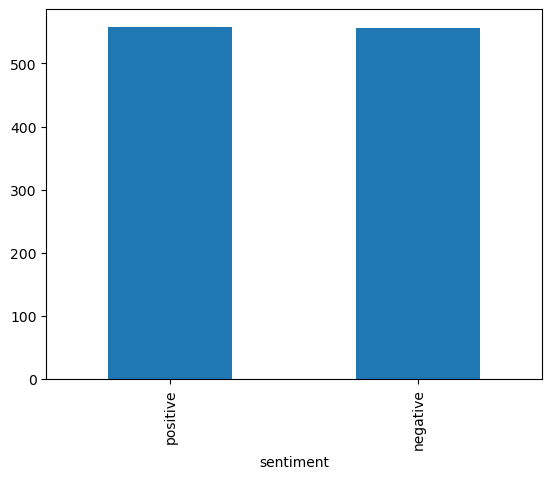

In [13]:
print(data.value_counts('sentiment'))
data.value_counts('sentiment').plot(kind='bar')

## Encode the sentiment label

In [16]:
map_dict = {'positive':1,
           'negative':0}
data['sentiment_numeric'] = data.sentiment.map(map_dict)
data.head()

,review,sentiment,sentiment_numeric
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [18]:
### Preprocessing Function
ps = PorterStemmer()
corpus = set()
def preprocess(text):
    ## removing unwanted space
    text = text.strip()
    ## removing html tags 
    text = re.sub("<[^>]*>", "",text)
    ## removing any numerical values
    text = re.sub('[^a-zA-Z]', ' ',text)
    ## lower case the word
    text = text.lower()
    # Remove the stop words
    text = text.split()
    text=[w for w in text if not w in eng_stop_words]
    ## stemming the word for sentiment analysis do not remove the stop word
    text = [ps.stem(word) for word in text]
    text = ' '.join(text)
    return text

In [20]:
data['Preprocessed_review'] = data.review.apply(preprocess)

In [21]:
data.head()

,review,sentiment,sentiment_numeric,Preprocessed_review
0,One of the other reviewers has mentioned that ...,positive,1,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,positive,1,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,positive,1,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,negative,0,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter mattei love time money visual stun film...


In [12]:
data.shape

(1114, 4)

In [21]:
data.sentiment_numeric

0       1
1       1
2       1
3       0
4       1
       ..
1109    1
1110    1
1111    1
1112    0
1113    1
Name: sentiment_numeric, Length: 1114, dtype: int64

In [30]:
### performing train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(data.Preprocessed_review,
                                                 data.sentiment_numeric,
                                                 test_size=0.2,
                                                 random_state=42,
   
                                                 stratify=data.sentiment_numeric)

In [32]:
x_train.shape,x_test.shape


((891,), (223,))

## Word Embedding Generation

**tf-idf**

In [34]:
#tf idf

tf_idf = TfidfVectorizer()

In [36]:
tf_idf

TfidfVectorizer()

In [38]:
#applying tf idf to training data

X_train_tf = tf_idf.fit_transform(x_train)
X_train_tf

<891x11806 sparse matrix of type '<class 'numpy.float64'>'
	with 83678 stored elements in Compressed Sparse Row format>

In [40]:
len(tf_idf.vocabulary_)

11806

In [42]:
list(tf_idf.vocabulary_.items())[:10]

[('sixth', 9490),
 ('escapad', 3388),
 ('freddi', 3955),
 ('krueger', 5750),
 ('final', 3725),
 ('manag', 6296),
 ('kill', 5662),
 ('virtual', 11284),
 ('everi', 3442),
 ('youth', 11754)]

In [44]:
X_train_tf.shape

(891, 11806)

In [46]:
X_train_tf[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

In [81]:
import numpy as np
np.argmax(X_train_tf[0].toarray()),np.max(X_train_tf[0].toarray())

(1461, 0.26618333662884025)

In [65]:
list(tf_idf.vocabulary_.items())[1460:1463]

[('window', 11570), ('passeng', 7583), ('peep', 7658)]

In [77]:
items=sorted(list(tf_idf.vocabulary_.items()))
items[1460:1463]

[('camelot', 1460), ('cameo', 1461), ('camera', 1462)]

In [79]:
x_train.values[0]

'sixth escapad freddi krueger final manag kill virtual everi youth springwood want broaden horizon spoiler need famili member order failur horror movi simpli scari work better dark macabr black comedi tell truth freddi krueger strip abil chill viewer mani wisecrack sure actor interest save robert englund alway obvious slum yaphet kotto simpli far mani visual effect final ok provid mani spark think one might hope ad new twist familiar dream killer stori provid englund opportun non makeup scene ever cameo worth note joint cameo coupl roseann tom arnold devoid entertain valu appropri appear veteran shock rocker alic cooper funni cameo johnni depp also sort acknowledg pop icon becom film debut breckin meyer play spencer one best thing replay key scene earlier entri close credit'

**Apply same on test data**

In [48]:
#applying tf idf to training data

X_test_tf = tf_idf.transform(x_test)
X_test_tf

<223x11806 sparse matrix of type '<class 'numpy.float64'>'
	with 18513 stored elements in Compressed Sparse Row format>

In [41]:
# tf_idf = TfidfVectorizer()
# X_train_tf = tf_idf.fit_transform(x_train)
# X_test_tf = tf_idf.transform(x_test)

**for original data we need to use fit_transform**

**for test data we need to use transform**

## Model creation

In [50]:
#naive bayes classifier
# X_train_tf  === embedding data review
# y_train  === encoded sentiment
naive_bayes_classifier = MultinomialNB()
naive_bayes_classifier.fit(X_train_tf,y_train)

MultinomialNB()

**Prediction**

In [95]:
X_test_tf

<223x11806 sparse matrix of type '<class 'numpy.float64'>'
	with 18513 stored elements in Compressed Sparse Row format>

In [52]:
#predicted y

y_pred = naive_bayes_classifier.predict(X_test_tf)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1], dtype=int64)

In [89]:
print(metrics.classification_report(y_test, 
                                    y_pred,
                                    target_names=['Positive', 'Negative']))

              precision    recall  f1-score   support

    Positive       0.77      0.88      0.82       111
    Negative       0.86      0.74      0.80       112

    accuracy                           0.81       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.81      0.81       223



In [91]:
print("Confusion matrix:")
print(metrics.confusion_matrix(y_test, y_pred))

Confusion matrix:
[[98 13]
 [29 83]]


In [97]:
# Doing test prediction
[x_test.values[0]]

['believ worst movi ever seen life laugh coupl time probabl stupid someon paid see movi plot horribl made sens act bad even tell tri movi terribl rate f']

In [58]:
#naive_bayes_classifier.predict(['i like movie'])

In [99]:
test_processed=preprocess(x_test.values[0]) # english

In [101]:
test_input = tf_idf.transform([test_processed]) # numbers

In [103]:
#0= bad review
#1= good review

res=naive_bayes_classifier.predict(test_input)[0]

if res==1:
    print("Good Review")
    
elif res==0:
    print("Bad Review")

Bad Review


In [30]:
y_test

162     0
1082    0
414     0
64      0
912     0
       ..
477     0
405     0
529     0
885     0
306     1
Name: sentiment_numeric, Length: 223, dtype: int64

In [64]:
### Testing all together
review=['Movie is good comedy works']
test_processed=preprocess(review[0])
test_input = tf_idf.transform([test_processed])
#0= bad review
#1= good review

res=naive_bayes_classifier.predict(test_input)[0]

if res==1:
    print("Good Review")
    
elif res==0:
    print("Bad Review")

Good Review


In [ ]:

- Preprocess

- Vectorizer

- Pass into the model

- Then model give predictions 1 and 0 


In [44]:
test_processed=preprocess("'pushpa movie is good but no comedy'")
test_input = tf_idf.transform([test_processed])
res=naive_bayes_classifier.predict(test_input)[0]
res

1

In [39]:
test_input

<1x11806 sparse matrix of type '<class 'numpy.float64'>'
	with 2 stored elements in Compressed Sparse Row format>